In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv("../data/raw/PhiUSIIL_Phishing_URL_Dataset.csv")
df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [21]:
df.shape

(235795, 56)

In [22]:
df.columns.tolist()

['FILENAME',
 'URL',
 'URLLength',
 'Domain',
 'DomainLength',
 'IsDomainIP',
 'TLD',
 'URLSimilarityIndex',
 'CharContinuationRate',
 'TLDLegitimateProb',
 'URLCharProb',
 'TLDLength',
 'NoOfSubDomain',
 'HasObfuscation',
 'NoOfObfuscatedChar',
 'ObfuscationRatio',
 'NoOfLettersInURL',
 'LetterRatioInURL',
 'NoOfDegitsInURL',
 'DegitRatioInURL',
 'NoOfEqualsInURL',
 'NoOfQMarkInURL',
 'NoOfAmpersandInURL',
 'NoOfOtherSpecialCharsInURL',
 'SpacialCharRatioInURL',
 'IsHTTPS',
 'LineOfCode',
 'LargestLineLength',
 'HasTitle',
 'Title',
 'DomainTitleMatchScore',
 'URLTitleMatchScore',
 'HasFavicon',
 'Robots',
 'IsResponsive',
 'NoOfURLRedirect',
 'NoOfSelfRedirect',
 'HasDescription',
 'NoOfPopup',
 'NoOfiFrame',
 'HasExternalFormSubmit',
 'HasSocialNet',
 'HasSubmitButton',
 'HasHiddenFields',
 'HasPasswordField',
 'Bank',
 'Pay',
 'Crypto',
 'HasCopyrightInfo',
 'NoOfImage',
 'NoOfCSS',
 'NoOfJS',
 'NoOfSelfRef',
 'NoOfEmptyRef',
 'NoOfExternalRef',
 'label']

In [23]:
df.dtypes

FILENAME                          str
URL                               str
URLLength                       int64
Domain                            str
DomainLength                    int64
IsDomainIP                      int64
TLD                               str
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                         int64
LineOfCode  

In [24]:
missing = df.isna().sum().sort_values(ascending=False)
missing.head(20)

FILENAME                0
URL                     0
URLLength               0
Domain                  0
DomainLength            0
IsDomainIP              0
TLD                     0
URLSimilarityIndex      0
CharContinuationRate    0
TLDLegitimateProb       0
URLCharProb             0
TLDLength               0
NoOfSubDomain           0
HasObfuscation          0
NoOfObfuscatedChar      0
ObfuscationRatio        0
NoOfLettersInURL        0
LetterRatioInURL        0
NoOfDegitsInURL         0
DegitRatioInURL         0
dtype: int64

In [25]:
for col in df.columns:
    unique_count = df[col].nunique()
    if unique_count < 10:
        print(col, df[col].unique())

IsDomainIP [0 1]
HasObfuscation [0 1]
NoOfQMarkInURL [0 1 3 2 4]
IsHTTPS [1 0]
HasTitle [1 0]
HasFavicon [0 1]
Robots [1 0]
IsResponsive [1 0]
NoOfURLRedirect [0 1]
NoOfSelfRedirect [0 1]
HasDescription [0 1]
HasExternalFormSubmit [0 1]
HasSocialNet [0 1]
HasSubmitButton [1 0]
HasHiddenFields [1 0]
HasPasswordField [0 1]
Bank [1 0]
Pay [0 1]
Crypto [0 1]
HasCopyrightInfo [1 0]
label [1 0]


In [26]:
df["label"].value_counts()

label
1    134850
0    100945
Name: count, dtype: int64

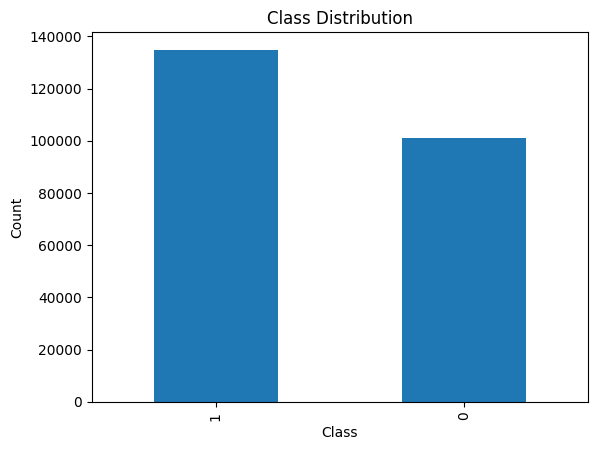

In [27]:
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [28]:
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
constant_cols

[]

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
print("Shape:", df.shape)
print("Missing values total:", df.isna().sum().sum())
print("Constant columns:", constant_cols)
print("Duplicate rows:", df.duplicated().sum())
print("Label distribution:\n", df["label"].value_counts())

Shape: (235795, 56)
Missing values total: 0
Constant columns: []
Duplicate rows: 0
Label distribution:
 label
1    134850
0    100945
Name: count, dtype: int64


In [31]:
label_counts = df["label"].value_counts()
label_percentages = df["label"].value_counts(normalize=True) * 100

print("Label counts:\n", label_counts)
print("\nLabel percentages:\n", label_percentages)

Label counts:
 label
1    134850
0    100945
Name: count, dtype: int64

Label percentages:
 label
1    57.189508
0    42.810492
Name: proportion, dtype: float64


In [32]:
for i, col in enumerate(df.columns):
    print(i, col)

0 FILENAME
1 URL
2 URLLength
3 Domain
4 DomainLength
5 IsDomainIP
6 TLD
7 URLSimilarityIndex
8 CharContinuationRate
9 TLDLegitimateProb
10 URLCharProb
11 TLDLength
12 NoOfSubDomain
13 HasObfuscation
14 NoOfObfuscatedChar
15 ObfuscationRatio
16 NoOfLettersInURL
17 LetterRatioInURL
18 NoOfDegitsInURL
19 DegitRatioInURL
20 NoOfEqualsInURL
21 NoOfQMarkInURL
22 NoOfAmpersandInURL
23 NoOfOtherSpecialCharsInURL
24 SpacialCharRatioInURL
25 IsHTTPS
26 LineOfCode
27 LargestLineLength
28 HasTitle
29 Title
30 DomainTitleMatchScore
31 URLTitleMatchScore
32 HasFavicon
33 Robots
34 IsResponsive
35 NoOfURLRedirect
36 NoOfSelfRedirect
37 HasDescription
38 NoOfPopup
39 NoOfiFrame
40 HasExternalFormSubmit
41 HasSocialNet
42 HasSubmitButton
43 HasHiddenFields
44 HasPasswordField
45 Bank
46 Pay
47 Crypto
48 HasCopyrightInfo
49 NoOfImage
50 NoOfCSS
51 NoOfJS
52 NoOfSelfRef
53 NoOfEmptyRef
54 NoOfExternalRef
55 label


In [33]:
object_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Object columns:", object_cols)

Object columns: ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']


C:\Users\Mohammad Farhan\AppData\Local\Temp\ipykernel_1476\3681342311.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [34]:
print(df["label"].dtype)
print(df["label"].unique())

int64
[1 0]


In [36]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [37]:
missing_summary = df.isna().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)
print(missing_summary)

Series([], dtype: int64)


In [38]:
X = df.drop(columns=["label"])
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (235795, 55)
y shape: (235795,)


In [39]:
print(X.dtypes.value_counts())

int64      40
float64    10
str         5
Name: count, dtype: int64


In [40]:
df.to_csv("../data/processed/dataset_v1.csv", index=False)

In [41]:
text_cols = ["FILENAME", "URL", "Domain", "TLD", "Title"]
df_baseline = df.drop(columns=text_cols)

X = df_baseline.drop(columns=["label"])
y = df_baseline["label"]

print(X.shape)
print(y.shape)
print(X.dtypes.value_counts())

(235795, 50)
(235795,)
int64      40
float64    10
Name: count, dtype: int64
